***
Module Title         : 	Capstone Project |
Assessment Title     :	Thesis  |
Supervisor Name        :	Kislay Raj  |
Date of Submission:
	Sunday, 7 September 2025, 11:59 PM  |
CCT College
***




                        Student Full Name    :  Johanna Riquelme A  |    Student Number  : 2023094

***

# *****************************************************************************

# Libraries

# *****************************************************************************

In [1]:
# pip install python-dp
# !pip install ipywidgets
# !pip install shap
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:

# Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns                                                                                   # Visualizations
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency                                                                # Statistical Methods
from sklearn.model_selection import train_test_split                                                    # models
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.preprocessing import  FunctionTransformer
from sklearn.pipeline import Pipeline                                                                   # Pipelines per model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support      # visualization
import tensorflow as tf                                                                                 # MLP (Keras)
from tensorflow.keras import Sequential, Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import sys
import shap
from scipy import sparse
from scipy.stats import spearmanr
from sklearn.datasets import load_breast_cancer

In [3]:
print(sys.executable)
import shap
print(shap.__version__)

C:\Users\johan\anaconda3\envs\tfenv\python.exe
0.48.0


In [4]:
# my path: C:\Users\johan\Documents\2023094_Capstone_2025
import os
print(os.getcwd())

C:\Users\johan\Documents\2023094_Capstone_2025


# *****************************************************************************

# Donwload and Clean dataset

# *****************************************************************************

In [5]:
# Website resource dataset: https://archive.ics.uci.edu/dataset/2/adult

# filename 
file_path = "C:/Users/johan/Documents/2023094_Capstone_2025/adult.data"

# Define column names from web site information
columns = [
    "Age", "Workclass", "Fnlwgt", "Education", "Education-num", 
    "Marital-status", "Occupation", "Relationship", "Race", 
    "Sex", "Capital-gain", "Capital-loss", "Hours-per-week", 
    "Native-country", "Income"
]

In [6]:
# Load the dataset
df = pd.read_csv(file_path, names=columns, na_values=" ?", skipinitialspace=True)

In [7]:
df.head(3)

,Age,Workclass,Fnlwgt,Education,Education-num,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [8]:
df['Occupation'].value_counts()

Occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [9]:
#  Define a order  education levels for data visualization 

Education_order = [
    '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college',
    'Assoc-voc', 'Assoc-acdm',
    'Bachelors', 'Masters', 'Prof-school', 'Doctorate'
]

In [10]:
# Convert Education column to ordered categorical
df['Education'] = pd.Categorical(
    df['Education'],
    categories=Education_order,
    ordered=True
)

In [11]:
# Sort 
df_sorted = df.sort_values('Education')

In [12]:
# Print to Check if there are inconsistent names
print(df['Education'].unique())

['Bachelors', 'HS-grad', '11th', 'Masters', '9th', ..., 'Prof-school', '5th-6th', '10th', NaN, '12th']
Length: 15
Categories (14, object): ['5th-6th' < '7th-8th' < '9th' < '10th' ... 'Bachelors' < 'Masters' < 'Prof-school' < 'Doctorate']


In [13]:
# with this last lines from 5 to 8 I can see much better the #  Visual Comparison code

# *****************************************************************************

# Thesis Alignment & EDA Plan

# *****************************************************************************

In [14]:
# Clean the Data, Drop rows with missing values
df.dropna(inplace=True)

In [15]:
# Basic Info 
# note my categorical variables : 6.-Occupation(object),  0.-Age(int64), 3.-Education(category) 
print(df.shape)
print(df.info())

(32342, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 32342 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Age             32342 non-null  int64   
 1   Workclass       32342 non-null  object  
 2   Fnlwgt          32342 non-null  int64   
 3   Education       32342 non-null  category
 4   Education-num   32342 non-null  int64   
 5   Marital-status  32342 non-null  object  
 6   Occupation      32342 non-null  object  
 7   Relationship    32342 non-null  object  
 8   Race            32342 non-null  object  
 9   Sex             32342 non-null  object  
 10  Capital-gain    32342 non-null  int64   
 11  Capital-loss    32342 non-null  int64   
 12  Hours-per-week  32342 non-null  int64   
 13  Native-country  32342 non-null  object  
 14  Income          32342 non-null  object  
dtypes: category(1), int64(6), object(8)
memory usage: 3.7+ MB
None


In [16]:
# Descriptive Statistics categorical only object
print(df.describe(include=['object']))

       Workclass      Marital-status      Occupation Relationship   Race  \
count      32342               32342           32342        32342  32342   
unique         9                   7              15            6      5   
top      Private  Married-civ-spouse  Prof-specialty      Husband  White   
freq       22519               14875            4135        13109  27644   

          Sex Native-country Income  
count   32342          32342  32342  
unique      2             42      2  
top      Male  United-States  <=50K  
freq    21633          29107  24507  


In [17]:
# To check a missing calues
df.isnull().sum()

Age               0
Workclass         0
Fnlwgt            0
Education         0
Education-num     0
Marital-status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital-gain      0
Capital-loss      0
Hours-per-week    0
Native-country    0
Income            0
dtype: int64

In [18]:
# Drop rows 
df.dropna(inplace=True)

In [19]:
# Count Income Classes
print(df['Income'].value_counts())

Income
<=50K    24507
>50K      7835
Name: count, dtype: int64


In [20]:
print(df.head(3))

   Age         Workclass  Fnlwgt  Education  Education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       Marital-status         Occupation   Relationship   Race   Sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   Capital-gain  Capital-loss  Hours-per-week Native-country Income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K  
2             0             0              40  United-States  <=50K  


In [21]:
# Replace "?" with "UnKnown" in ocupation Column
df['Occupation'] = df['Occupation'].replace('?', 'Unknown')

In [22]:
# Select Quasi-Identifiers, these 3 can uniquely identify people in a dataset — so they need protection.
qis = ["Age", "Education", "Occupation"]

In [23]:
# Group by Quasi-Identifiers, Pandas only considers actual (Qis) values present in the dataset
grouped = df.groupby(qis, observed=True)

In [24]:
# Apply k-Anonymity (Filter Groups With at Least k Records)
# k-Anonymity rule: Every group of QIs(Age, Education, Occupation)  must appear at least k times in the dataset.
k = 5
anon_df = df[df.groupby(qis, observed=True)[qis[0]].transform("count") >= k]

In [25]:
# Display Basic Statistics

print(f"Original dataset size: {len(df)}")                                      # Shows How many rows before anonymization.
print(f"Dataset size after applying k-anonymity (k={k}): {len(anon_df)}")       # How many remain after applying k-anonymity.
print(f"Percentage of data retained: {100 * len(anon_df) / len(df):.2f}%")      # What percentage of the data is still usable.


Original dataset size: 32342
Dataset size after applying k-anonymity (k=5): 25410
Percentage of data retained: 78.57%


In [26]:
# Show Sample of Anonymized Groups
sample = anon_df.groupby(qis, observed=True).size().reset_index(name='group_size')
print(sample.head(10))


   Age Education         Occupation  group_size
0   17       9th      Other-service          15
1   17      10th  Handlers-cleaners           8
2   17      10th      Other-service          56
3   17      10th              Sales          28
4   17      10th            Unknown          32
5   17      11th       Adm-clerical          16
6   17      11th       Craft-repair           8
7   17      11th  Handlers-cleaners          25
8   17      11th      Other-service          42
9   17      11th    Priv-house-serv           6


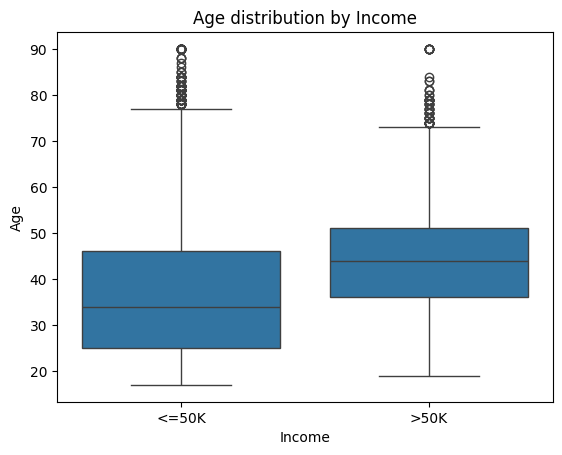

In [27]:
# Income by age
sns.boxplot(x='Income', y='Age', data=df)
plt.title('Age distribution by Income')
plt.show()

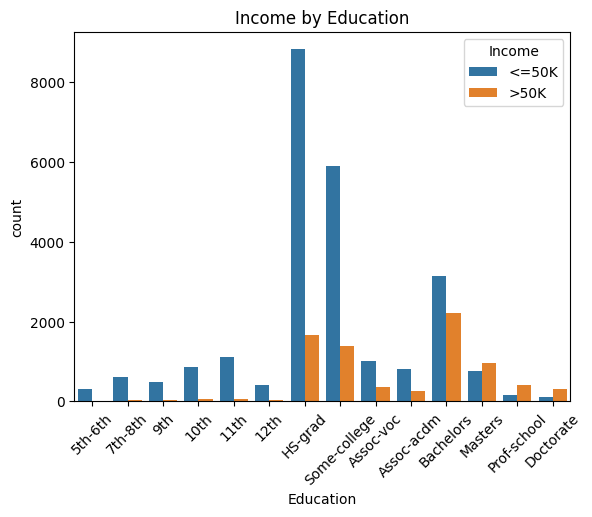

In [28]:
# Income by education
sns.countplot(x='Education', hue='Income', data=df)
plt.xticks(rotation=45)
plt.title('Income by Education')
plt.show()

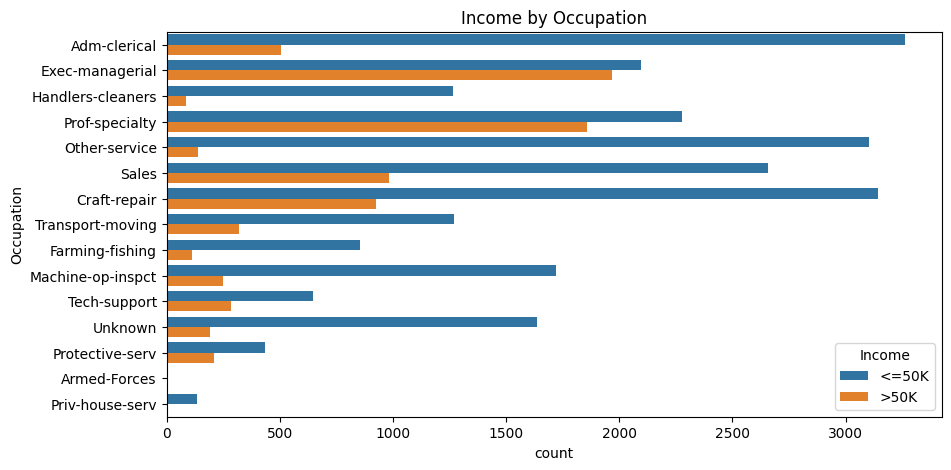

In [29]:
# Income by occupation
plt.figure(figsize=(10,5))
sns.countplot(y='Occupation', hue='Income', data=df)
plt.title('Income by Occupation')
plt.show()

# *****************************************************************************

# Hypothesis Testing Plan

# *****************************************************************************

In [30]:

# Contingency table: income vs education (before and after anonymization)
crosstab_original = pd.crosstab(df['Education'], df['Income'])
crosstab_anon = pd.crosstab(anon_df['Education'], anon_df['Income'])

chi2, p, dof, expected = chi2_contingency(crosstab_original)

print(f"Chi-squared: {chi2}")
print(f"p-value: {p}")

Chi-squared: 4356.651192997481
p-value: 0.0


In [31]:
#  Print & Compare Both Crosstabs
print("Original Crosstab:\n", crosstab_original)
print("\nAnonymized Crosstab:\n", crosstab_anon)

Original Crosstab:
 Income        <=50K  >50K
Education                
5th-6th         317    16
7th-8th         606    40
9th             487    27
10th            871    62
11th           1115    60
12th            400    33
HS-grad        8826  1675
Some-college   5904  1387
Assoc-voc      1021   361
Assoc-acdm      802   265
Bachelors      3134  2221
Masters         764   959
Prof-school     153   423
Doctorate       107   306

Anonymized Crosstab:
 Income        <=50K  >50K
Education                
5th-6th           4     1
7th-8th          79     3
9th              38     0
10th            291    15
11th            518    10
12th             96     0
HS-grad        8290  1571
Some-college   5391  1252
Assoc-voc       465   165
Assoc-acdm      359   128
Bachelors      2707  1994
Masters         543   793
Prof-school      87   323
Doctorate        71   216


In [32]:
# Run Chi-squared on Anonymized Data Too
chi2_anon, p_anon, dof_anon, expected_anon = chi2_contingency(crosstab_anon)

print(f"\n[Anonymized] Chi-squared: {chi2_anon}")
print(f"[Anonymized] p-value: {p_anon}")


[Anonymized] Chi-squared: 3424.0347048282365
[Anonymized] p-value: 0.0


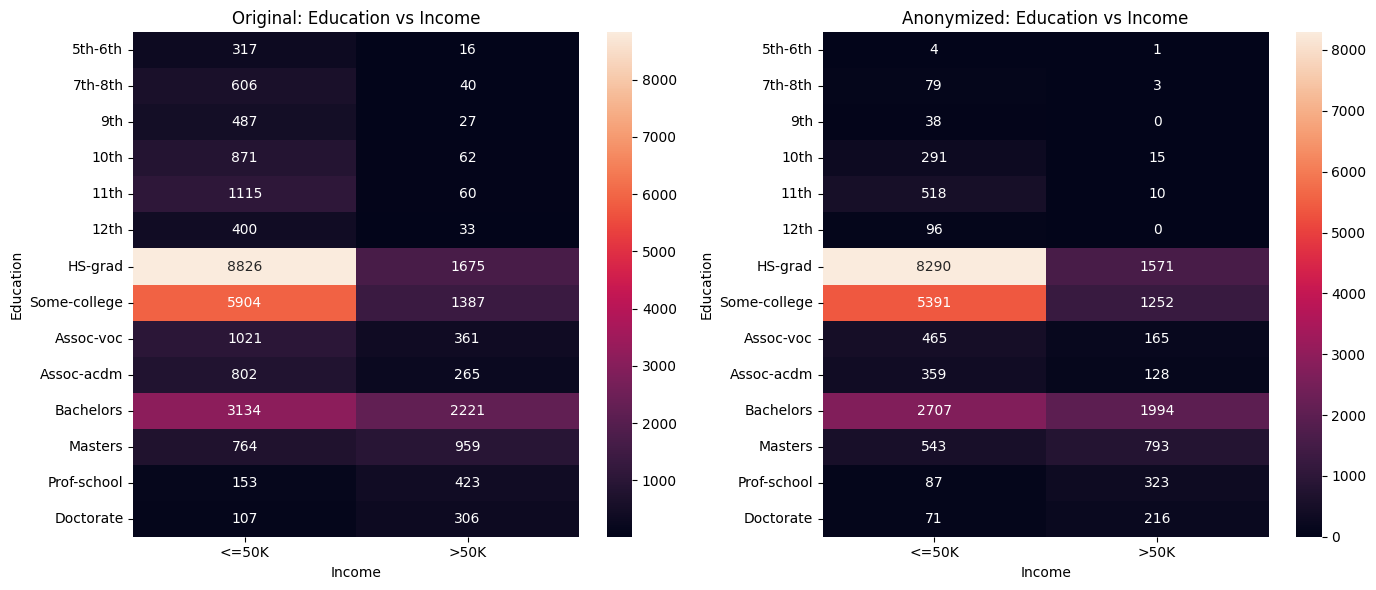

In [33]:
#  Visual Comparison 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(crosstab_original, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Original: Education vs Income")

sns.heatmap(crosstab_anon, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Anonymized: Education vs Income")

plt.tight_layout()
plt.show()

In [34]:
# Contingency table: income vs sex (before and after anonymization)
crosstab_sex = pd.crosstab(df['Sex'], df['Income'])
crosstab_sex_anon = pd.crosstab(anon_df['Sex'], anon_df['Income'])
chi2, p, dof, expected = chi2_contingency(crosstab_sex)

print(f"Chi-squared: {chi2}")
print(f"p-value: {p}")

Chi-squared: 1522.2957009176853
p-value: 0.0


In [35]:
#  Print & Compare Both Crosstabs
print("Original Crosstab:\n", crosstab_sex)
print("\nAnonymized Crosstab:\n", crosstab_sex_anon)

Original Crosstab:
 Income  <=50K  >50K
Sex                
Female   9530  1179
Male    14977  6656

Anonymized Crosstab:
 Income  <=50K  >50K
Sex                
Female   7687  1005
Male    11252  5466


In [36]:
# Run Chi-squared on Anonymized Data Too
chi2_anon, p_anon, dof_anon, expected_anon = chi2_contingency(crosstab_sex_anon)

print(f"\n[Anonymized] Chi-squared: {chi2_anon}")
print(f"[Anonymized] p-value: {p_anon}")


[Anonymized] Chi-squared: 1344.4379515584444
[Anonymized] p-value: 2.4908950875561517e-294


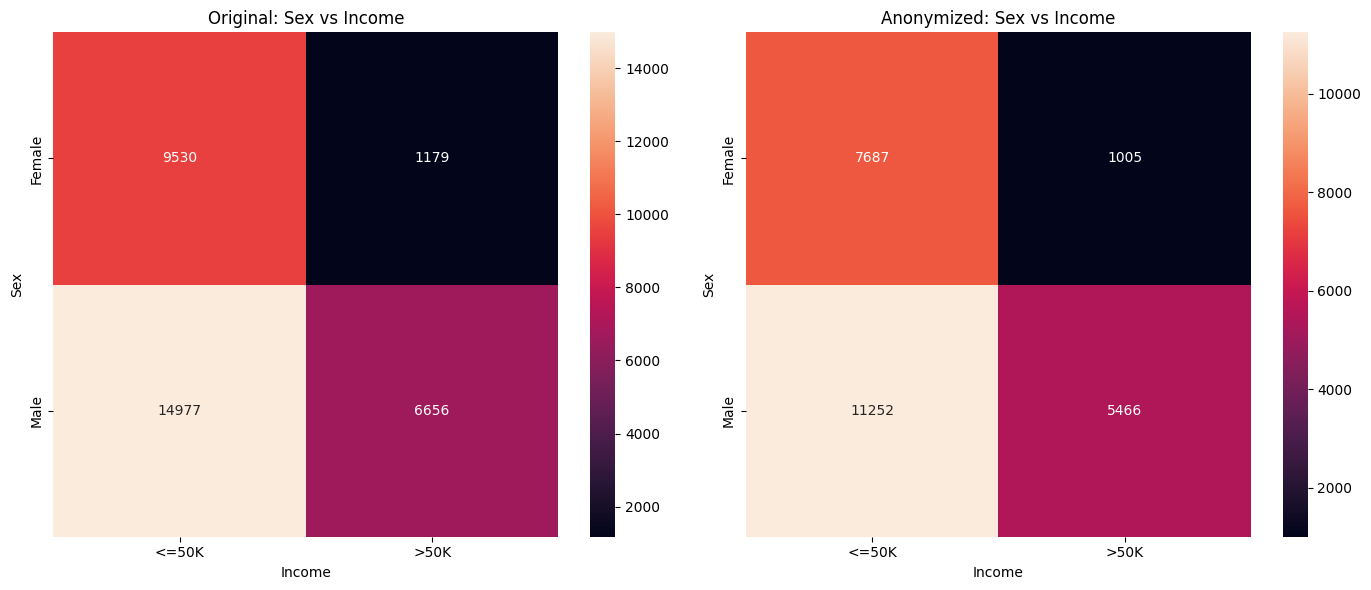

In [37]:
#  Visual Comparison 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(crosstab_sex, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Original: Sex vs Income")

sns.heatmap(crosstab_sex_anon, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Anonymized: Sex vs Income")

plt.tight_layout()
plt.show()

In [38]:
# Tabla 1 Example of k-Anonymity Filtering in the Adult Dataset

qis = ["Age", "Education", "Occupation"]
k = 5

anon_group_table = (
    anon_df.groupby(qis, observed=True)
           .size()
           .reset_index(name="Count of Records")
)

anon_group_table_k = (
    anon_group_table[anon_group_table["Count of Records"] >= k]
        .sort_values(["Count of Records"] + qis, ascending=[False, True, True, True])
        .reset_index(drop=True)
)

anon_group_table_k.head(7)

,Age,Education,Occupation,Count of Records
0,19,Some-college,Other-service,80
1,20,Some-college,Unknown,78
2,20,Some-college,Other-service,77
3,21,Some-college,Other-service,77
4,37,HS-grad,Craft-repair,77
5,35,HS-grad,Craft-repair,74
6,20,Some-college,Adm-clerical,73


# *****************************************************************************

# Preprocessing (ORIGINAL Data)
## Load data & define target/features

# *****************************************************************************

In [39]:
# Reusable: build preprocess for a given feature matrix X
def build_preprocess(X, cat_cols=None):
    num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
    if cat_cols is None:
        cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

    gainloss_cols = [c for c in ['capital-gain', 'capital-loss'] if c in num_cols]
    num_other = [c for c in num_cols if c not in gainloss_cols]

    gainloss_pipe = Pipeline(steps=[
        ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scaler', StandardScaler())
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ('num_other', StandardScaler(), num_other),
            ('gainloss', gainloss_pipe, gainloss_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ],
        remainder='drop'
    )
    return preprocess, num_cols, cat_cols, gainloss_cols, num_other



In [40]:
# Reusable: train+report for a sklearn pipeline model
def train_eval_pipe(pipe, X_train, y_train, X_test, y_test, name="Model"):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred))
    return y_pred



In [41]:
# Reusable: build a simple MLP
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [42]:
# Encoding Categorical Variables

df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

In [43]:
# Splitting Features and Target Variable >50K'=1, '<=50K'=0 this info will see in confusion matrix
X = df.drop(columns=['Income'])
y = df['Income'].map({'>50K':1, '<=50K':0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

assert len(X_train) == len(y_train)
assert len(X_test)  == len(y_test)

In [44]:
# Preprocessing (ORIGINAL) — define ONCE
preprocess, num_cols, cat_cols, gainloss_cols, num_other = build_preprocess(X)

# *****************************************************************************

# Pipelines by model (ORIGINAL) — reuse preprocess
### This keeps preprocessing + model together (less bugs, easier comparison).

# *****************************************************************************

In [45]:
#***********************    L O G I S T I C  R E G R E S S I O N  - L R     ***********************

In [46]:
# Logistic Regression Pipeline
pipe_lr = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=1000))])
_ = train_eval_pipe(pipe_lr, X_train, y_train, X_test, y_test, name="Logistic Regression (orig)")


Logistic Regression (orig) accuracy: 0.849
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4902
           1       0.74      0.58      0.65      1567

    accuracy                           0.85      6469
   macro avg       0.81      0.76      0.78      6469
weighted avg       0.84      0.85      0.84      6469



In [47]:

#  FIT on training split Logistic Regression
pipe_lr.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_other', ...), ('gainloss', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Model: Logistic Regression LR – Confusion Matrix


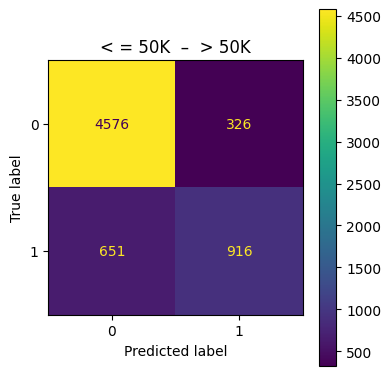

In [48]:
# Predict on the test set
y_pred_lr = pipe_lr.predict(X_test)
#  Confusion matrix for a quick visual check
fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax)
print("Model: Logistic Regression LR – Confusion Matrix")
ax.set_title("< = 50K  –  > 50K")
plt.tight_layout()
plt.show()

In [49]:
#******************************    D E C I S I O N   T R E E   C L A S S I F I E R   D T     ******************************

In [50]:
# Decision Tree Pipeline
pipe_dt = Pipeline([('prep', preprocess), ('clf', DecisionTreeClassifier(random_state=42))])
_ = train_eval_pipe(pipe_dt, X_train, y_train, X_test, y_test, name="Decision Tree (orig)")

Decision Tree (orig) accuracy: 0.814
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4902
           1       0.62      0.61      0.61      1567

    accuracy                           0.81      6469
   macro avg       0.75      0.74      0.75      6469
weighted avg       0.81      0.81      0.81      6469



In [51]:
#  FIT on training split Decision Tree
pipe_dt.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_other', ...), ('gainloss', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Model: Decision Tree DT – Confusion Matrix


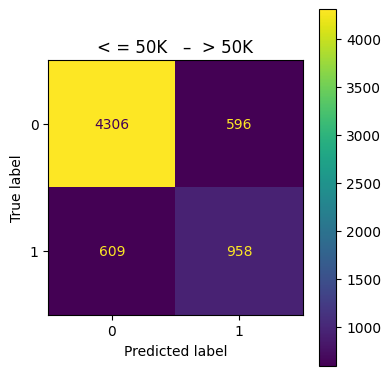

In [52]:
# Predict on the test set
y_pred_dt = pipe_dt.predict(X_test)
#  Confusion matrix for a quick visual check
fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=ax)
print("Model: Decision Tree DT – Confusion Matrix")
ax.set_title("< = 50K   –  > 50K")
plt.tight_layout()
plt.show()

In [53]:
# Calc Confusion Matrix basic,Model Comparison
confusion_matrix(y_test, y_pred_dt)

array([[4306,  596],
       [ 609,  958]])

In [54]:
# *****************************************************************************

# MLP (Keras)
### Multilayer Perceptron (MLP) Neural Network

In [55]:
# *****************************************************************************

In [56]:
#******************************    M U L T I L A Y E R S   P E R C E P T R O N   M L P  (ORIGINAL) ******************************

In [57]:
# MLP (ORIGINAL) — uses transformed arrays
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre  = preprocess.transform(X_test)


In [58]:
# safety checks
assert X_train_pre.shape[0] == len(y_train)
assert X_test_pre.shape[0]  == len(y_test)

In [59]:

#  build and train the MLP
mlp = build_mlp(X_train_pre.shape[1])
mlp.fit(X_train_pre, y_train, epochs=15, batch_size=32, validation_split=0.2,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=1)


C:\Users\johan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7989 - loss: 0.4144 - val_accuracy: 0.8493 - val_loss: 0.3227
Epoch 2/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8530 - loss: 0.3235 - val_accuracy: 0.8539 - val_loss: 0.3193
Epoch 3/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8542 - loss: 0.3119 - val_accuracy: 0.8504 - val_loss: 0.3194
Epoch 4/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8629 - loss: 0.3032 - val_accuracy: 0.8541 - val_loss: 0.3180
Epoch 5/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8576 - loss: 0.3020 - val_accuracy: 0.8524 - val_loss: 0.3185
Epoch 6/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8578 - loss: 0.3029 - val_accuracy: 0.8529 - val_loss: 0.3178
Epoch 7/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8554 - loss: 0.3053 - val_accuracy: 0.8539 - val_loss: 0.3183
Epoch 8/15
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8612 - loss: 0.2978 - val_accuracy: 0.

In [60]:
# evaluate
loss, acc = mlp.evaluate(X_test_pre, y_test, verbose=0)
print(f"MLP (orig) accuracy: {acc:.3f}")

MLP (orig) accuracy: 0.855


In [61]:
# ---- ORIGINAL MLP ----
y_proba_orig = mlp.predict(X_test_pre, verbose=0).ravel()
y_pred_orig = (y_proba_orig >= 0.5).astype(int)

acc_orig = accuracy_score(y_test, y_pred_orig)
prec_orig, rec_orig, f1_orig, _ = precision_recall_fscore_support(
    y_test, y_pred_orig, average='weighted', zero_division=0
)

# Side-by-side results table

In [62]:
# Logistic Regression (pipeline)
y_pred_lr = pipe_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr, rec_lr, f1_lr, _ = precision_recall_fscore_support(
    y_test, y_pred_lr, average='weighted', zero_division=0
)

In [63]:
# Decision Tree (pipeline)
y_pred_dt = pipe_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt, rec_dt, f1_dt, _ = precision_recall_fscore_support(
    y_test, y_pred_dt, average='weighted', zero_division=0
)

In [64]:
# ---- ORIGINAL MLP ----
y_proba_orig = mlp.predict(X_test_pre, verbose=0).ravel()
y_pred_orig = (y_proba_orig >= 0.5).astype(int)

acc_orig = accuracy_score(y_test, y_pred_orig)
prec_orig, rec_orig, f1_orig, _ = precision_recall_fscore_support(
    y_test, y_pred_orig, average='weighted', zero_division=0
)

In [65]:
# ----  Base results (Logistic Regression + Decision Tree) ----
results = pd.DataFrame([
    ['Logistic Regression', acc_lr, prec_lr, rec_lr, f1_lr],
    ['Decision Tree',       acc_dt, prec_dt, rec_dt, f1_dt]
], columns=['Model', 'Accuracy', 'Precision(w)', 'Recall(w)', 'F1(w)'])

# ----  Append MLP results ----
mlp_results = pd.DataFrame([
    ['MLP (Original)', acc_orig, prec_orig, rec_orig, f1_orig],
#    ['MLP (Anonymized)', acc_anon, prec_anon, rec_anon, f1_anon]
], columns=['Model', 'Accuracy', 'Precision(w)', 'Recall(w)', 'F1(w)'])

results = pd.concat([results, mlp_results], ignore_index=True)

# ----  Show final table ----
print(results)

                 Model  Accuracy  Precision(w)  Recall(w)     F1(w)
0  Logistic Regression  0.848972      0.842042   0.848972  0.842658
1        Decision Tree  0.813727      0.813205   0.813727  0.813462
2       MLP (Original)  0.854537      0.848346   0.854537  0.849019


In [66]:
# Assemble a tidy results table
results = pd.DataFrame(
    [
        ['Logistic Regression', acc_lr, prec_lr, rec_lr, f1_lr],
        ['Decision Tree',       acc_dt, prec_dt, rec_dt, f1_dt],
        ['MLP (Original)',      acc_orig, prec_orig, rec_orig, f1_orig],
#        ['MLP (Anonymized)',    acc_anon, prec_anon, rec_anon, f1_anon],
    ],
    columns=['Model', 'Accuracy', 'Precision(w)', 'Recall(w)', 'F1(w)']
)

results

,Model,Accuracy,Precision(w),Recall(w),F1(w)
0,Logistic Regression,0.848972,0.842042,0.848972,0.842658
1,Decision Tree,0.813727,0.813205,0.813727,0.813462
2,MLP (Original),0.854537,0.848346,0.854537,0.849019


In [67]:
# Extract columns for plotting
models = results['Model'].tolist()
acc    = results['Accuracy'].tolist()
prec   = results['Precision(w)'].tolist()
rec    = results['Recall(w)'].tolist()
f1     = results['F1(w)'].tolist()

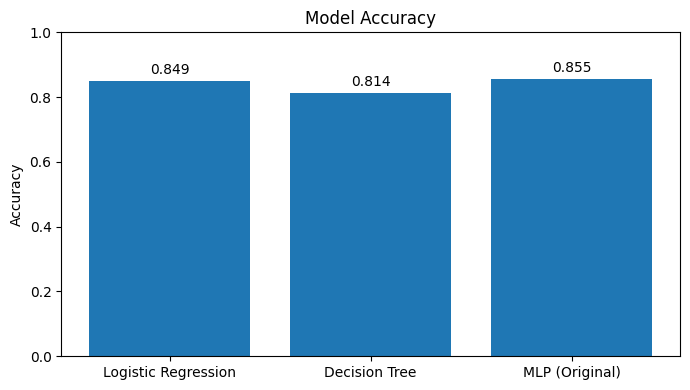

In [68]:
# -------- A) Accuracy --------
plt.figure(figsize=(7,4))
bars = plt.bar(models, acc)
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.ylim(0, 1.0)
# Add value labels
try:
    import matplotlib
    if hasattr(matplotlib.pyplot, "bar_label"):
        plt.bar_label(bars, fmt='%.3f', padding=3)
    else:
        for i, v in enumerate(acc):
            plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
except Exception:
    for i, v in enumerate(acc):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()



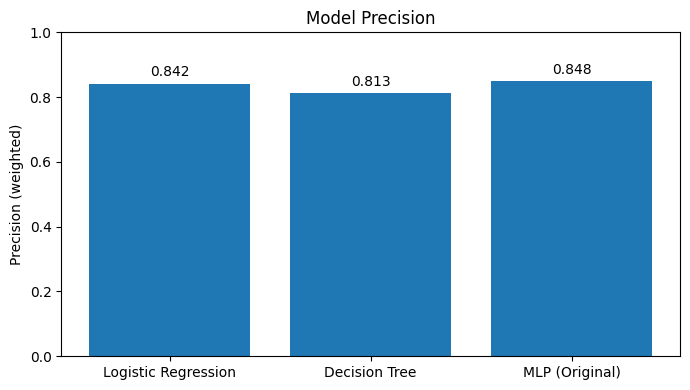

In [69]:
# -------- B) Precision --------
plt.figure(figsize=(7,4))
bars = plt.bar(models, prec)
plt.ylabel('Precision (weighted)')
plt.title('Model Precision')
plt.ylim(0, 1.0)
try:
    plt.bar_label(bars, fmt='%.3f', padding=3)
except Exception:
    for i, v in enumerate(prec):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()


In [70]:
# -------- C) Recall --------

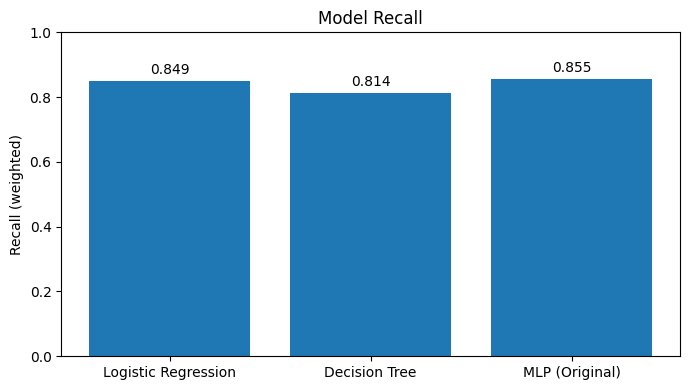

In [71]:
# -------- C) Recall --------
plt.figure(figsize=(7,4))
bars = plt.bar(models, rec)
plt.ylabel('Recall (weighted)')
plt.title('Model Recall')
plt.ylim(0, 1.0)
try:
    plt.bar_label(bars, fmt='%.3f', padding=3)
except Exception:
    for i, v in enumerate(rec):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()


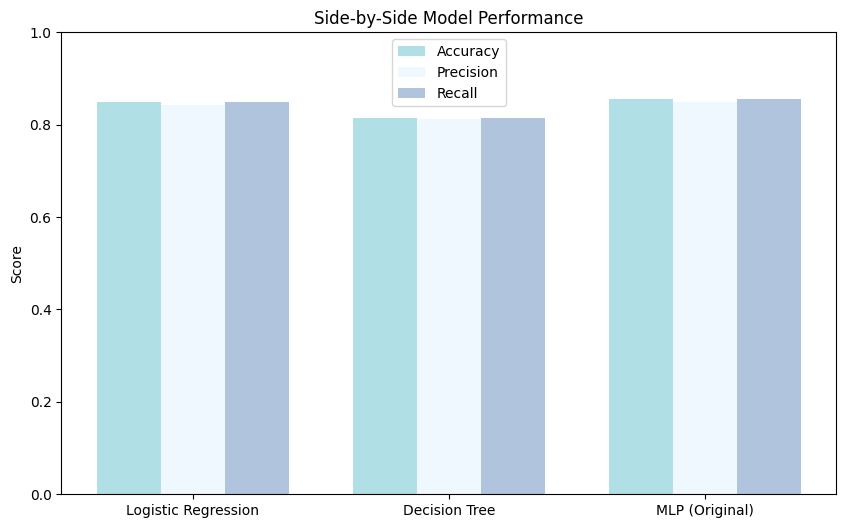

In [72]:
# -------- D) Grouped side-by-side --------
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
r1 = plt.bar(x - width, acc, width, label='Accuracy', color='powderblue')   
r2 = plt.bar(x,         prec, width, label='Precision', color='aliceblue') 
r3 = plt.bar(x + width, rec, width, label='Recall',    color='lightsteelblue') 
# CSS Color from: https://matplotlib.org/stable/gallery/color/named_colors.html
plt.ylabel('Score')
plt.title('Side-by-Side Model Performance')
plt.xticks(x, models)
plt.ylim(0, 1.0)
plt.legend()


## LR, DT and MLP Conclusion:
### Based on the evaluation metrics, the MLP (Neural Network) model achieved the highest accuracy (0.856), along with the best precision (0.850) and best recall (0.856) among all tested models. This indicates that the neural network approach not only predicts most cases correctly but also maintains a strong balance between correctly identifying positive cases and avoiding false positives. Therefore, for this dataset, the MLP model is the best-performing option compared to Logistic Regression and Decision Tree classifiers.

# Training on the anonymized dataset to compare

In [73]:
# anonymized dataset anon_df  ( Age | Education | Occupation | Income)
X_anon = anon_df.drop(columns=['Income'])
y_anon = anon_df['Income'].map({'>50K':1, '<=50K':0})

#Split the anonymized dataset into training and testing sets. Parameters:test_size=0.2 -> 20% to Testing: 80% to Training
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_anon, y_anon, test_size=0.2, stratify=y_anon, random_state=42
)

In [74]:
# Identify numerical (Age, HoursPerWeek) vs categorical(Education, Occupation) features 
# X_anon / y_anon already defined from anon_df
num_cols_a = X_anon.select_dtypes(include=[np.number]).columns
cat_cols_a = X_anon.select_dtypes(include=['object','category']).columns
# Build a preprocessing pipeline with ColumnTransformer
preprocess_a = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_a),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_a)
    ],
    remainder='drop'
)

In [75]:
#******************************    P I P E R L I N E   LR  DT (ANONYMIZED)  ******************************

In [76]:
# Logistic Regression pipeline (Anon Data)
pipe_lr_a = Pipeline([('prep', preprocess_a), ('clf', LogisticRegression(max_iter=1000))])
pipe_lr_a.fit(X_train_a, y_train_a)
y_pred_lr_a = pipe_lr_a.predict(X_test_a)

acc_lr_a = accuracy_score(y_test_a, y_pred_lr_a)
prec_lr_a, rec_lr_a, f1_lr_a, _ = precision_recall_fscore_support(
    y_test_a, y_pred_lr_a, average='weighted', zero_division=0
)


In [77]:
# Train Logistic Regression pipeline (Anon Data)

print('Anon Logistic Regression acc:', accuracy_score(y_test_a, pipe_lr_a.predict(X_test_a)))


Anon Logistic Regression acc: 0.8486816214088941


In [78]:
#  FIT on training split Logistic Regression
pipe_lr.fit(X_train_a, y_train_a)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_other', ...), ('gainloss', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
# ***** DT *****

In [80]:
# Decision Tree (anonymized) ===
pipe_dt_a = Pipeline([('prep', preprocess_a), ('clf', DecisionTreeClassifier(random_state=42))])
pipe_dt_a.fit(X_train_a, y_train_a)
y_pred_dt_a = pipe_dt_a.predict(X_test_a)

acc_dt_a = accuracy_score(y_test_a, y_pred_dt_a)
prec_dt_a, rec_dt_a, f1_dt_a, _ = precision_recall_fscore_support(
    y_test_a, y_pred_dt_a, average='weighted', zero_division=0
)

In [81]:
# Train decision tree pipeline (Anon Data)

print('Anon Decision Tree acc:', accuracy_score(y_test_a, pipe_dt_a.predict(X_test_a)))

Anon Decision Tree acc: 0.8067689885871704


In [82]:
# --- Decision Tree (Anon) ---
pipe_dt_a.fit(X_train_a, y_train_a)
y_pred_dt_a = pipe_dt_a.predict(X_test_a)
acc_dt_a = accuracy_score(y_test_a, y_pred_dt_a)

In [83]:
# Keras neural networks (MLP) uses the transformed arrays
X_train_a_pre = preprocess_a.fit_transform(X_train_a)
X_test_a_pre  = preprocess_a.transform(X_test_a)

In [84]:
# Sanity checks: shapes MUST match
print(X_train_a_pre.shape, len(y_train_a))      # rows of features; (20328, 105) 20328
print(X_test_a_pre.shape,  len(y_test_a))       # rows of target labels; (5082, 105) 5082

(20328, 105) 20328
(5082, 105) 5082


In [85]:
# assert, safety check in Python.
assert X_train_a_pre.shape[0] == len(y_train_a), "Train X/y size mismatch"
assert X_test_a_pre.shape[0]  == len(y_test_a),  "Test X/y size mismatch"

In [86]:
# Building MLP (Multilayer Perceptron) Neural Network.   Dropout(0.3)= 30% Randomly drops



In [87]:
#******************************    M U L T I L A Y E R S   P E R C E P T R O N   M L P  (ANONYMIZED)  ******************************

In [88]:
# Build anonymized dataset (k-anonymity already done → anon_df)
# anon_df = ...  # your anonymized dataframe
X_anon = anon_df.drop(columns=['Income'])
y_anon = anon_df['Income'].map({'>50K':1, '<=50K':0})

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_anon, y_anon, test_size=0.2, stratify=y_anon, random_state=42
)

assert len(X_train_a) == len(y_train_a)
assert len(X_test_a)  == len(y_test_a)


In [89]:
# Preprocessing (ANONYMIZED) — define ONCE
preprocess_a, num_cols_a, cat_cols_a, gainloss_cols_a, num_other_a = build_preprocess(X_anon)

In [90]:
# Pipelines by model (ANONYMIZED) — reuse preprocess_a
# Logistic Regression (anon)
pipe_lr_a = Pipeline([('prep', preprocess_a), ('clf', LogisticRegression(max_iter=1000))])
_ = train_eval_pipe(pipe_lr_a, X_train_a, y_train_a, X_test_a, y_test_a, name="Logistic Regression (anon)")

Logistic Regression (anon) accuracy: 0.849
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      3788
           1       0.73      0.65      0.69      1294

    accuracy                           0.85      5082
   macro avg       0.81      0.78      0.79      5082
weighted avg       0.84      0.85      0.85      5082



In [91]:
# Decision Tree (anon)
pipe_dt_a = Pipeline([('prep', preprocess_a), ('clf', DecisionTreeClassifier(random_state=42))])
_ = train_eval_pipe(pipe_dt_a, X_train_a, y_train_a, X_test_a, y_test_a, name="Decision Tree (anon)")

Decision Tree (anon) accuracy: 0.807
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      3788
           1       0.62      0.64      0.63      1294

    accuracy                           0.81      5082
   macro avg       0.75      0.75      0.75      5082
weighted avg       0.81      0.81      0.81      5082



In [92]:
# MLP (ANONYMIZED) — uses transformed arraysX_train_a_pre = preprocess_a.fit_transform(X_train_a)
X_train_a_pre = preprocess_a.fit_transform(X_train_a)
X_test_a_pre  = preprocess_a.transform(X_test_a)

In [93]:
# safety checks
assert X_train_a_pre.shape[0] == len(y_train_a)
assert X_test_a_pre.shape[0]  == len(y_test_a)

In [94]:
# build and train the MLP
mlp_a = build_mlp(X_train_a_pre.shape[1])
mlp_a.fit(X_train_a_pre, y_train_a, epochs=15, batch_size=32, validation_split=0.2,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
          verbose=1)

Epoch 1/15


C:\Users\johan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7784 - loss: 0.4351 - val_accuracy: 0.8421 - val_loss: 0.3265
Epoch 2/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8510 - loss: 0.3153 - val_accuracy: 0.8483 - val_loss: 0.3198
Epoch 3/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8498 - loss: 0.3152 - val_accuracy: 0.8465 - val_loss: 0.3177
Epoch 4/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8540 - loss: 0.3108 - val_accuracy: 0.8460 - val_loss: 0.3185
Epoch 5/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8551 - loss: 0.3041 - val_accuracy: 0.8451 - val_loss: 0.3190
Epoch 6/15
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8571 - loss: 0.3090 - val_accuracy: 0.8460 - val_loss: 0.3183


In [95]:
# evaluate
loss_a, acc_a = mlp_a.evaluate(X_test_a_pre, y_test_a, verbose=0)
print(f"MLP (anon) accuracy: {acc_a:.3f}")

MLP (anon) accuracy: 0.853


In [96]:
# ---- ANONYMIZED MLP ----
y_proba_anon = mlp_a.predict(X_test_a_pre, verbose=0).ravel()
y_pred_anon = (y_proba_anon >= 0.5).astype(int)

In [97]:
acc_anon = accuracy_score(y_test_a, y_pred_anon)
prec_anon, rec_anon, f1_anon, _ = precision_recall_fscore_support(
    y_test_a, y_pred_anon, average='weighted', zero_division=0
)

In [98]:
# ---- ANONYMIZED MLP ----
y_proba_anon = mlp_a.predict(X_test_a_pre, verbose=0).ravel()
y_pred_anon = (y_proba_anon >= 0.5).astype(int)

acc_anon = accuracy_score(y_test_a, y_pred_anon)
prec_anon, rec_anon, f1_anon, _ = precision_recall_fscore_support(
    y_test_a, y_pred_anon, average='weighted', zero_division=0
)

In [99]:
# === 3) MLP (anonymized) — use a CLONE of preprocess_a (do not refit the pipeline’s preprocessor) ===
from sklearn.base import clone
pre_nn_a = clone(preprocess_a)
X_train_a_pre = pre_nn_a.fit_transform(X_train_a)
X_test_a_pre  = pre_nn_a.transform(X_test_a)

In [100]:
# Build MLP without input_shape warning: use an Input layer
from tensorflow.keras import Input, Sequential
from tensorflow.keras.layers import Dense, Dropout

mlp_a = Sequential([
    Input(shape=(X_train_a_pre.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
mlp_a.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mlp_a.fit(
    X_train_a_pre, y_train_a,
    epochs=15, batch_size=32, validation_split=0.2,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=0
)


In [101]:
# Evaluate + metrics for MLP (anon)
y_proba_anon = mlp_a.predict(X_test_a_pre, verbose=0).ravel()
y_pred_anon = (y_proba_anon >= 0.5).astype(int)

acc_anon = accuracy_score(y_test_a, y_pred_anon)
prec_anon, rec_anon, f1_anon, _ = precision_recall_fscore_support(
    y_test_a, y_pred_anon, average='weighted', zero_division=0
)

print(f"[ANON] LR acc={acc_lr_a:.3f} | DT acc={acc_dt_a:.3f} | MLP acc={acc_anon:.3f}")

[ANON] LR acc=0.849 | DT acc=0.807 | MLP acc=0.851


# *****************************************************************************

# A tidy table ( and side-by-side comparison metrics by model)

In [102]:
results = pd.DataFrame([
    ['Logistic Regression (Original)', acc_lr,  prec_lr,  rec_lr,  f1_lr],
    ['Decision Tree (Original)',       acc_dt,  prec_dt,  rec_dt,  f1_dt],
    ['MLP (Original)',                 acc_orig,prec_orig,rec_orig,f1_orig],
    ['Logistic Regression (Anon)',     acc_lr_a,prec_lr_a,rec_lr_a,f1_lr_a],
    ['Decision Tree (Anon)',           acc_dt_a,prec_dt_a,rec_dt_a,f1_dt_a],
    ['MLP (Anon)',                     acc_anon,prec_anon,rec_anon,f1_anon],
], columns=['Model','Accuracy','Precision(w)','Recall(w)','F1(w)'])

results

,Model,Accuracy,Precision(w),Recall(w),F1(w)
0,Logistic Regression (Original),0.848972,0.842042,0.848972,0.842658
1,Decision Tree (Original),0.813727,0.813205,0.813727,0.813462
2,MLP (Original),0.854537,0.848346,0.854537,0.849019
3,Logistic Regression (Anon),0.848682,0.844249,0.848682,0.845612
4,Decision Tree (Anon),0.806769,0.808899,0.806769,0.807773
5,MLP (Anon),0.851436,0.848123,0.851436,0.849354


In [103]:
for var in ["acc_lr","acc_dt","acc_orig","acc_lr_a","acc_dt_a","acc_anon"]:
    print(var, "exists" if var in globals() else "MISSING")

acc_lr exists
acc_dt exists
acc_orig exists
acc_lr_a exists
acc_dt_a exists
acc_anon exists


In [104]:
# Make a copy with cleaner labels (Original vs Anon)
plot_df = results.copy()
plot_df['Model'] = plot_df['Model'].str.replace(' (Original)', '', regex=False)
plot_df['Model'] = plot_df['Model'].str.replace(' (Anon)', '', regex=False)

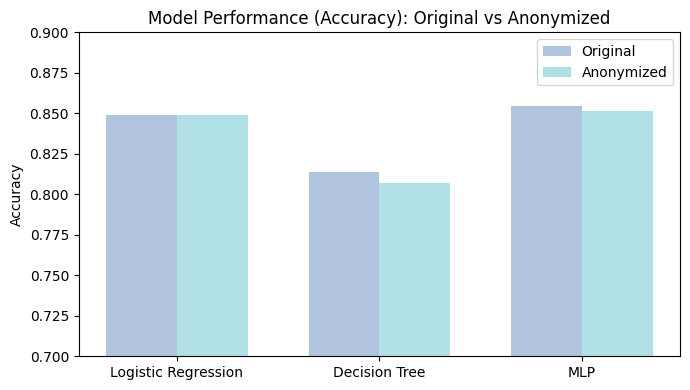

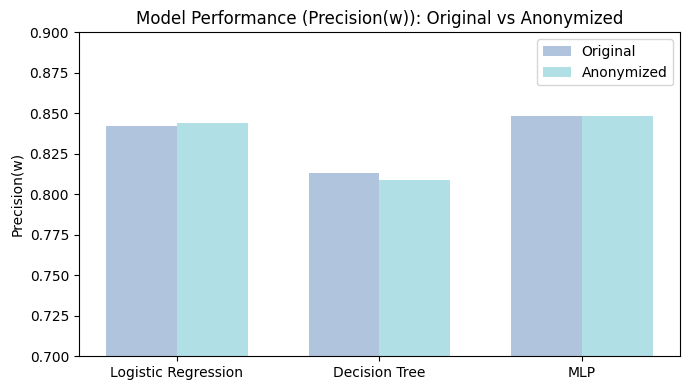

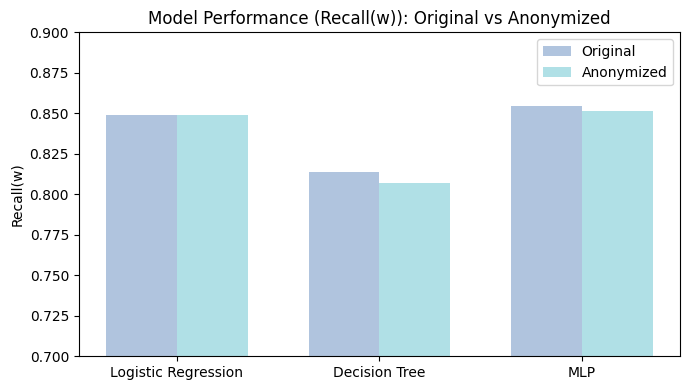

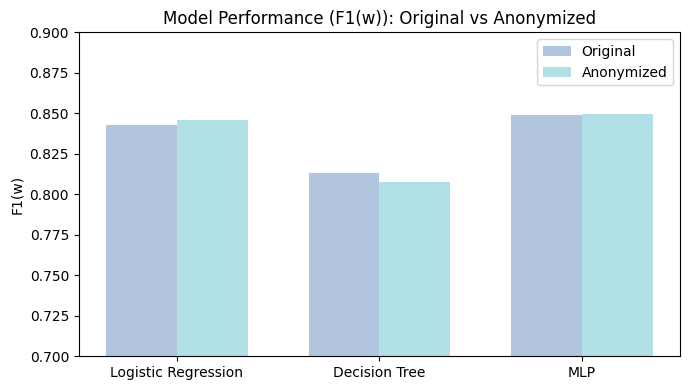

In [105]:
# Separate Original vs Anon
orig = plot_df.iloc[0:3].set_index('Model')
anon = plot_df.iloc[3:6].set_index('Model')

metrics = ['Accuracy','Precision(w)','Recall(w)','F1(w)']
models  = orig.index.tolist()
x = np.arange(len(models))
width = 0.35

for metric in metrics:
    plt.figure(figsize=(7,4))
    plt.bar(x - width/2, orig[metric], width, label='Original', color='lightsteelblue')
    plt.bar(x + width/2, anon[metric], width, label='Anonymized', color='powderblue')

    plt.xticks(x, models)
    plt.ylabel(metric)
    plt.title(f'Model Performance ({metric}): Original vs Anonymized')
    plt.ylim(0.7, 0.9)   # adjust if needed
    plt.legend()
    plt.tight_layout()
    plt.show()

# Shap

In [106]:
# Keeping the Data in Mind
print(df.head(7))

   Age         Workclass  Fnlwgt  Education  Education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   
5   37           Private  284582    Masters             14   
6   49           Private  160187        9th              5   

          Marital-status         Occupation   Relationship   Race     Sex  \
0          Never-married       Adm-clerical  Not-in-family  White    Male   
1     Married-civ-spouse    Exec-managerial        Husband  White    Male   
2               Divorced  Handlers-cleaners  Not-in-family  White    Male   
3     Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4     Married-civ-spouse     Prof-specialty           Wife  Black  Female   
5     Married-civ-spouse    Exec-manageri

In [107]:
# The top-10 features by average Shapley value for Logistic Regression.

In [108]:
# loading transformer and classifier from pipeline
transformer = pipe_lr.named_steps['prep']   # ColumnTransformer
clf         = pipe_lr.named_steps['clf']    # LogisticRegression 

#  Transform data to the numeric space the model uses
X_train_t = transformer.transform(X_train)
X_test_t  = transformer.transform(X_test)

In [109]:
# Create SHAP explainer (baseline)
expl_lr = shap.Explainer(clf, X_train_t)

# Explain one test row
i = 0

# Make a 2-D slice so shape is (1, n_features)
row = X_test_t[i:i+1]

# Explain that single row
shap_row = expl_lr(row)

In [110]:
# Feature names after preprocessing
try:
    feature_names_orig = transformer.get_feature_names_out()
except Exception:
    feature_names_orig = [f"feat_{i}" for i in range(X_train_t.shape[1])]

# Build explainer and COMPUTE shap_lr  
try:
    expl_lr = shap.LinearExplainer(clf, X_train_t, feature_perturbation="interventional")
except Exception:
    expl_lr = shap.Explainer(clf, X_train_t)

shap_lr = expl_lr(X_test_t[:300])  # <-- this creates shap_lr

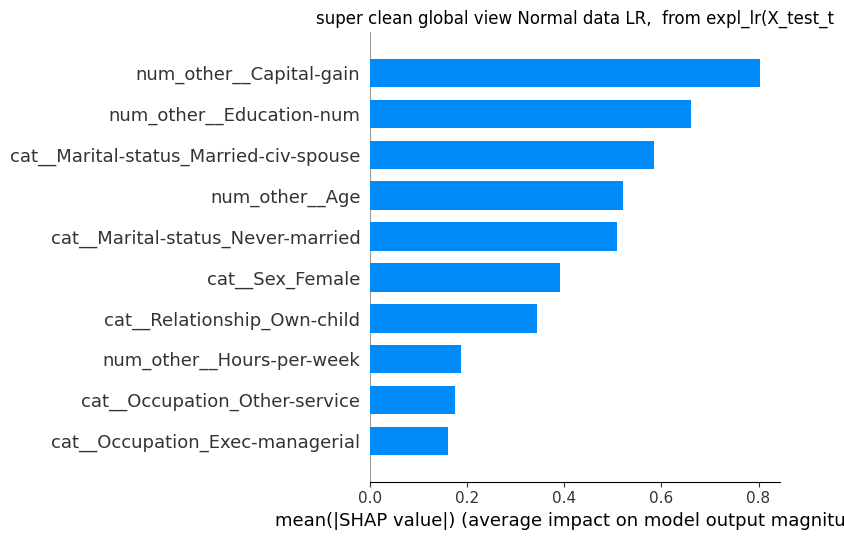

In [111]:
# Force plot 
# Top-10 features by mean |SHAP| — super clean global view Normal data
plt.title("super clean global view Normal data LR,  from expl_lr(X_test_t")
shap.summary_plot(
    shap_lr.values,                 # from expl_lr(X_test_t[:300])
    X_test_t[:300],
    feature_names=feature_names_orig,
    plot_type='bar',
    max_display=10
)

In [112]:
# The top-10 features by average Shapley value for Logistic Regression Anonyzed data,

In [113]:
# Get feature names from the fitted transformer
try:
    feature_names_anon = transformer.get_feature_names_out()
except Exception:
    feature_names_anon = [f"feat_{i}" for i in range(X_train_a_t.shape[1])]

In [114]:
# visalization with shap to see LR Anonymized model
# Grab steps and transform anonymized splits
transformer = pipe_lr.named_steps['prep']     # your ColumnTransformer
clf         = pipe_lr.named_steps['clf']      # LogisticRegression

X_train_a_t = transformer.transform(X_train_a)
X_test_a_t  = transformer.transform(X_test_a)

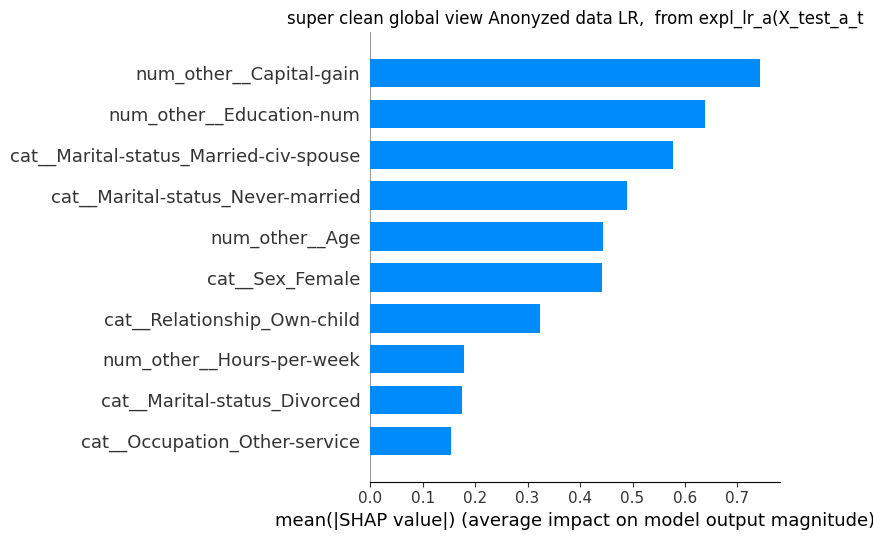

In [115]:

# Build explainer and COMPUTE shap_lr_a

expl_lr_a = shap.Explainer(clf, X_train_a_t)
shap_lr_a = expl_lr_a(X_test_a_t[:300])
# Force plot 
# Top-10 features by mean |SHAP| — super clean global view Anonyzed data
plt.title("super clean global view Anonyzed data LR,  from expl_lr_a(X_test_a_t")
shap.summary_plot(
    shap_lr_a.values,               # from expl_lr_a(X_test_a_t[:300])
    X_test_a_t[:300],
    feature_names=feature_names_anon,
    plot_type='bar',
    max_display=10
)

In [116]:
# explanation:
# with the pipeline, which is already in line 46
# pipe_lr = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=1000))])
# _ = train_eval_pipe(pipe_lr, X_train, y_train, X_test, y_test, name="Logistic Regression (orig)")
# Prepare transformed matrices + feature names
# (ORIGINAL data, Logistic Regression)

In [117]:
# here is the same preprocessor that lives inside in trained pipeline
prep_orig = pipe_lr.named_steps['prep']

In [118]:
# Transform with the fitted preprocessor (do NOT fit again)
X_train_t = prep_orig.transform(X_train)
X_test_t  = prep_orig.transform(X_test)

In [119]:
print("features len =", len(feature_names_orig))
print("shap shape   =", getattr(shap_lr.values, "shape", None))

features len = 105
shap shape   = (300, 105)


In [120]:
# 1) Mean absolute SHAP per transformed column
mean_abs_shap = np.mean(np.abs(shap_lr.values), axis=0)
df = pd.DataFrame({"feature": feature_names_orig, "mean_abs_shap": mean_abs_shap})

In [121]:
edu_mask = df["feature"].str.contains("Education_", case=False, regex=False) | \
           df["feature"].str.contains("Education-num", case=False, regex=False)

sex_mask = df["feature"].str.contains("Sex", case=False, regex=False)

relationship_mask = df["feature"].str.contains("Marital-status", case=False, regex=False)

age_mask = df["feature"].str.contains("Age", case=False, regex=False)

In [122]:
# 3) Totals
edu_total = df.loc[edu_mask, "mean_abs_shap"].sum()
age_total = df.loc[age_mask, "mean_abs_shap"].sum()
sex_total = df.loc[sex_mask, "mean_abs_shap"].sum()
relationship_total = df.loc[relationship_mask, "mean_abs_shap"].sum()
print(f"Education total mean|SHAP| = {edu_total:.4f}")
print(f"Age total mean|SHAP|       = {age_total:.4f}")
print(f"sex total mean|SHAP|       = {sex_total:.4f}")
print(f"relationship total mean|SHAP|       = {relationship_total:.4f}")

Education total mean|SHAP| = 0.9669
Age total mean|SHAP|       = 0.6822
sex total mean|SHAP|       = 0.4337
relationship total mean|SHAP|       = 1.2977


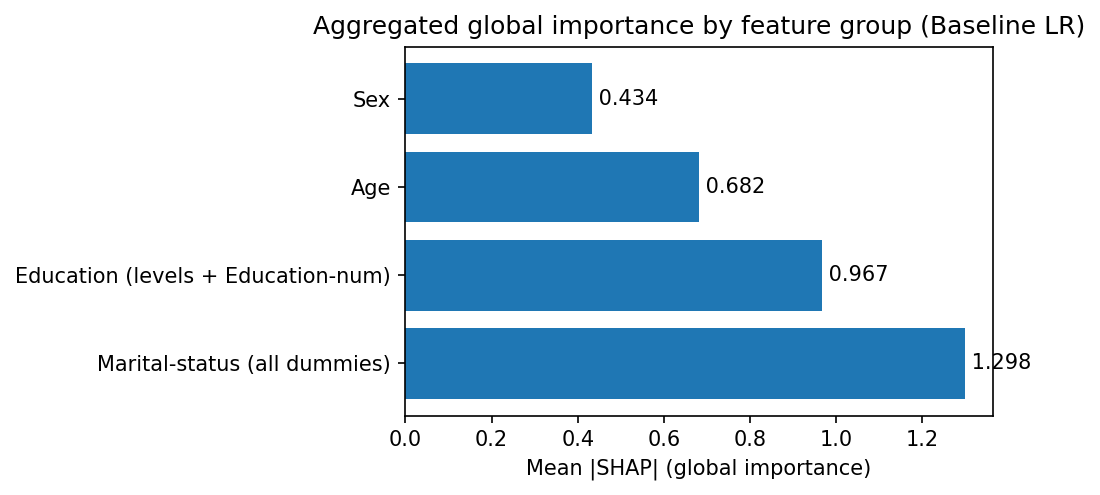

In [123]:
# 4) Plot: Education vs Age (global importance)
labels = ["Marital-status (all dummies)", "Education (levels + Education-num)", "Age", "Sex"]
values = [relationship_total, edu_total, age_total, sex_total]

fig, ax = plt.subplots(figsize=(7, 3.4), dpi=150)
ax.barh(labels, values)
ax.set_xlabel("Mean |SHAP| (global importance)")
ax.set_title("Aggregated global importance by feature group (Baseline LR)")
for y, v in enumerate(values):
    ax.text(v, y, f" {v:.3f}", va="center")
plt.tight_layout()
plt.show()

In [124]:
# Predict P(>50K) with your fitted pipeline
proba = pipe_lr.predict_proba(X_test)[:, 1]


In [125]:
# Join to raw X_test for grouping
tmp = X_test.copy()
tmp = tmp.assign(pred_proba=proba)

In [126]:
# Column names (adjust if needed)
ms_col = "Marital-status"   # e.g., 'Marital-status'
sex_col = "Sex"             # e.g., 'Sex'

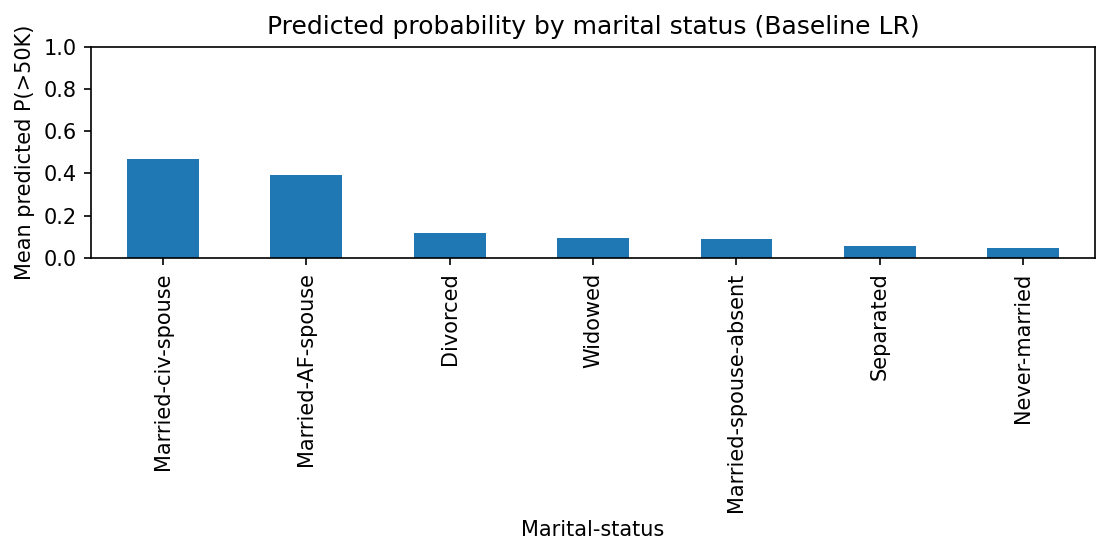

In [127]:
# --- (A) Full breakdown by each marital-status category ---
ms_mean = tmp.groupby(ms_col)["pred_proba"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 3.8), dpi=150)
ms_mean.plot(kind="bar", ax=ax)
ax.set_ylabel("Mean predicted P(>50K)")
ax.set_title("Predicted probability by marital status (Baseline LR)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

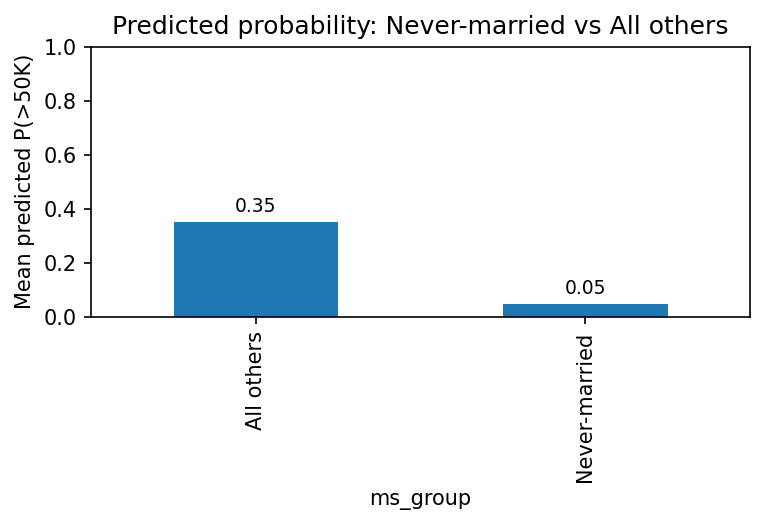

In [128]:
# --- (B) Collapsed view: Never-married vs All others ---
tmp["ms_group"] = np.where(tmp[ms_col].str.lower().eq("never-married"), "Never-married", "All others")
ms2_mean = tmp.groupby("ms_group")["pred_proba"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5.2, 3.6), dpi=150)
ms2_mean.plot(kind="bar", ax=ax)
ax.set_ylabel("Mean predicted P(>50K)")
ax.set_title("Predicted probability: Never-married vs All others")
ax.set_ylim(0, 1)
for i, v in enumerate(ms2_mean.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

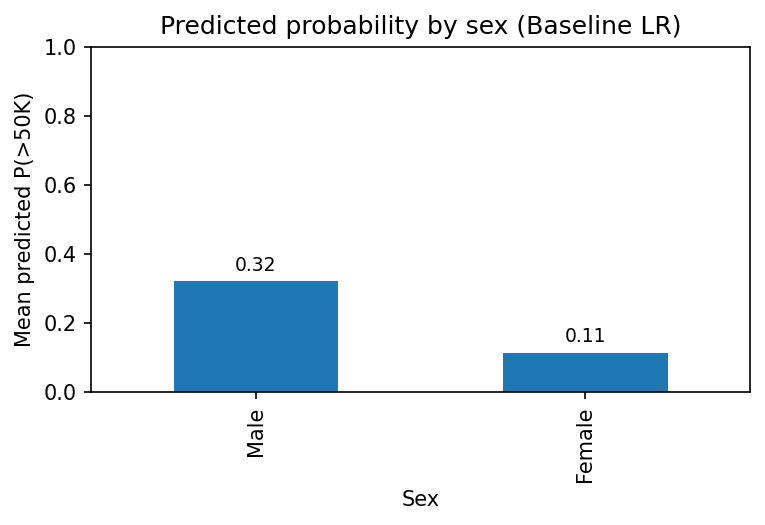

In [129]:
sex_mean = tmp.groupby(sex_col)["pred_proba"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5.2, 3.6), dpi=150)
sex_mean.plot(kind="bar", ax=ax)
ax.set_ylabel("Mean predicted P(>50K)")
ax.set_title("Predicted probability by sex (Baseline LR)")
ax.set_ylim(0, 1)
for i, v in enumerate(sex_mean.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [130]:
# 1) Predicted probability on the original (raw) X_test
proba = pipe_lr.predict_proba(X_test)[:, 1]

# 2) Join with raw X_test columns for plotting
tmp = X_test.copy()
tmp = tmp.assign(pred_proba=proba)

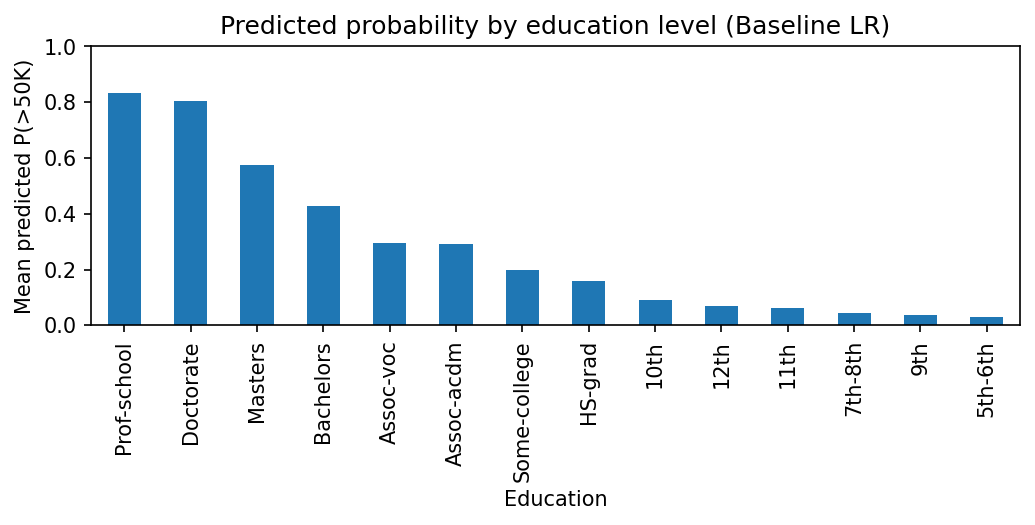

In [131]:
# --- By Education (categorical) ---
edu_col = "Education"   # <-- set to your exact column name in X_test
edu_order = None        # or provide a custom order list if you have one

edu_mean = tmp.groupby(edu_col)["pred_proba"].mean().sort_values(ascending=False)
if edu_order:
    edu_mean = edu_mean.reindex(edu_order)

fig, ax = plt.subplots(figsize=(7, 3.6), dpi=150)
edu_mean.plot(kind="bar", ax=ax)
ax.set_ylabel("Mean predicted P(>50K)")
ax.set_title("Predicted probability by education level (Baseline LR)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

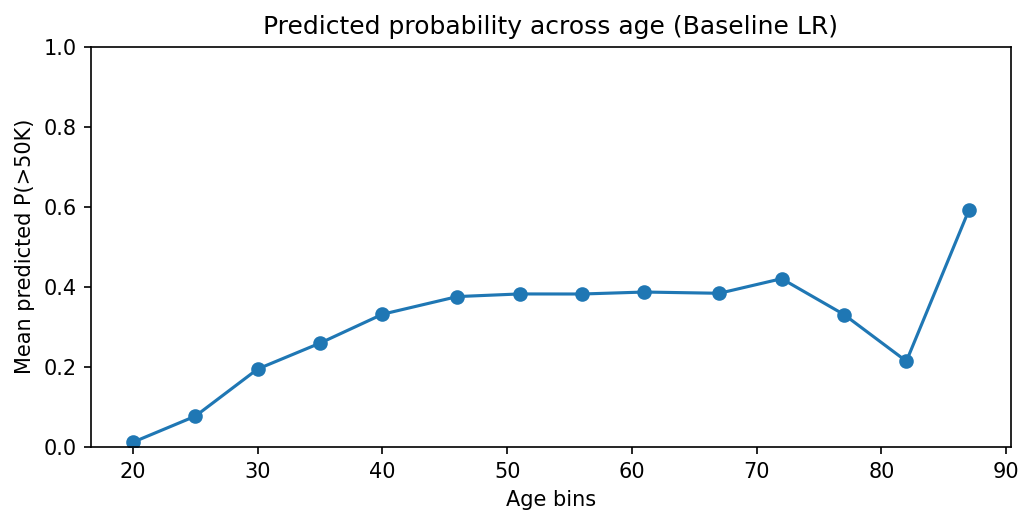

In [132]:
# --- By Age (continuous, smoothed by bins) ---
age_col = "Age"         # <-- Dataset Age variable
# Create bins
bins = np.linspace(tmp[age_col].min(), tmp[age_col].max(), 15)
age_bin = pd.cut(tmp[age_col], bins=bins, include_lowest=True)

# Compute mean predicted probability per bin
age_mean = tmp.groupby(age_bin)["pred_proba"].mean()
# --- Relabel the index to use bin midpoints (integers) ---
bin_midpoints = [interval.mid for interval in age_mean.index]
age_mean.index = np.round(bin_midpoints).astype(int)

# Plot
fig, ax = plt.subplots(figsize=(7, 3.6), dpi=150)
age_mean.plot(ax=ax, marker="o")

ax.set_xlabel("Age bins")
ax.set_ylabel("Mean predicted P(>50K)")
ax.set_title("Predicted probability across age (Baseline LR)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [133]:
# Turns the original features into the numeric matrix the model uses (scaled numbers + one-hot encoded categories).
# Builds the list of feature names that match those columns (needed for SHAP plots).

In [134]:
# here is the same preprocessor that lives inside in trained pipeline
prep_anon = pipe_lr_a.named_steps['prep']

In [135]:
# Transform with the fitted preprocessor (do NOT fit again)
X_train_a_t = prep_anon.transform(X_train_a)
X_test_a_t  = prep_anon.transform(X_test_a)

In [136]:

# Try the modern, simplest way first:
try:
    feature_names_anon = prep_anon.get_feature_names_out()
except Exception:
    # Manual rebuild (robust across sklearn versions)
    names_a = []
    for name, trans, cols in prep_anon.transformers_:
        if name == 'cat':
            ohe_a = prep_anon.named_transformers_['cat']
            try:
                ohe_names_a = ohe_a.get_feature_names_out()                 # modern sklearn
            except TypeError:
                ohe_names_a = ohe_a.get_feature_names_out(ohe_a.feature_names_in_)  # fallback
            names_a.extend(ohe_names_a)
        else:
            # 'num_other' and 'gainloss' just pass-through original column names
            names_a.extend(list(cols))
    feature_names_anon = np.array(names_a)

In [137]:
# Sanity check: columns must align
assert X_test_a_t.shape[1] == len(feature_names_anon), (
    X_test_a_t.shape, len(feature_names_anon)
)

In [138]:
# Build SHAP explainer for Logistic Regression (anonymized)
expl_lr_a = shap.Explainer(
    pipe_lr_a.named_steps['clf'],
    X_test_a_t,  # background = anonymized test set
    feature_names=feature_names_anon
)

# Compute SHAP values for first 300 rows
shap_lr_a = expl_lr_a(X_test_a_t[:300])

In [139]:
# 
# Build explainer + compute SHAP values (ORIGINAL LR)
#

In [140]:
# With this code is take a small background sample from the TRAIN matrix (keeps SHAP fast & stable)
bg_orig = shap.sample(X_train_t, 200, random_state=42)

In [141]:
# here create a masker that assumes features act independently 
masker_orig = shap.maskers.Independent(bg_orig)

In [142]:
#  Building a LinearExplainer for my trained LR model
lr_orig = pipe_lr.named_steps['clf']
expl_lr = shap.LinearExplainer(lr_orig, masker_orig)

In [143]:
# Explain a subset of TEST rows (e.g., first 300 for speed)
shap_lr = expl_lr(X_test_t[:300])

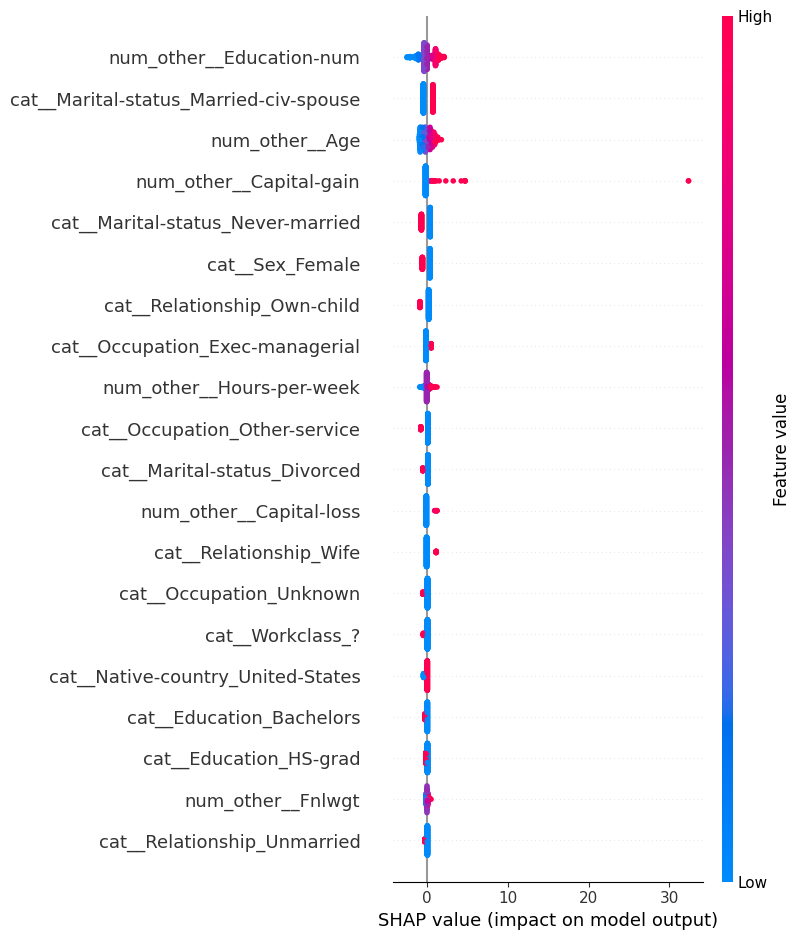

In [144]:
# Plot a global summary (which features drive predictions most)
shap.summary_plot(shap_lr.values, X_test_t[:300], feature_names=feature_names_orig)

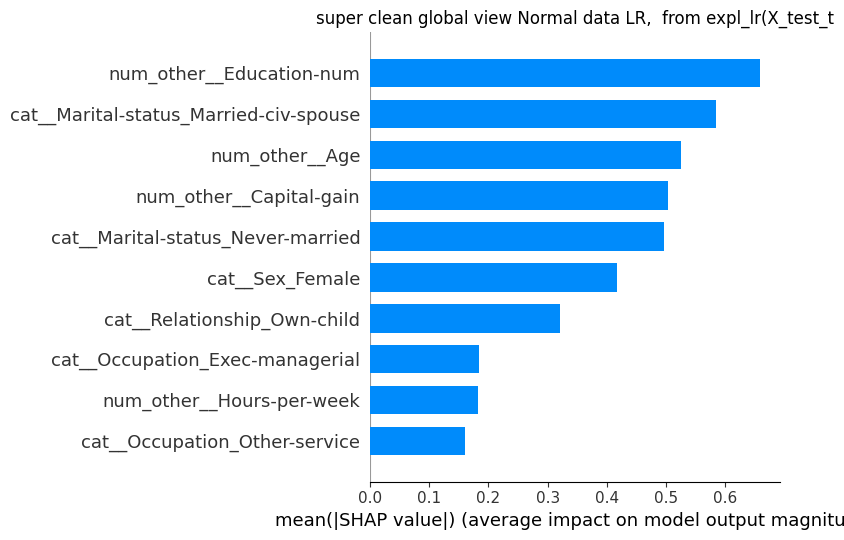

In [145]:

# Pick one test row (example: row 0 from the test set)
i = 0

# Make a 2-D slice so shape is (1, n_features)
row = X_test_t[i:i+1]

# Explain that single row
shap_row = expl_lr(row)
# Get the raw feature values for display (dense 1-D array)
if sparse.issparse(row):
    feat_values = row.toarray()[0]
else:
    feat_values = np.asarray(row)[0]
 # Force plot 
# Top-10 features by mean |SHAP| — super clean global view Normal data
plt.title("super clean global view Normal data LR,  from expl_lr(X_test_t")
shap.summary_plot(
    shap_lr.values,                 # from expl_lr(X_test_t[:300])
    X_test_t[:300],
    feature_names=feature_names_orig,
    plot_type='bar',
    max_display=10
)   

In [146]:
# Pick one test row (example: row 0 from the test set)
i = 0

# Make a 2-D slice so shape is (1, n_features)
row = X_test_t[i:i+1]

# Explain that single row
shap_row = expl_lr(row)

In [147]:
# Get the raw feature values for display (dense 1-D array)
if sparse.issparse(row):
    feat_values = row.toarray()[0]
else:
    feat_values = np.asarray(row)[0]

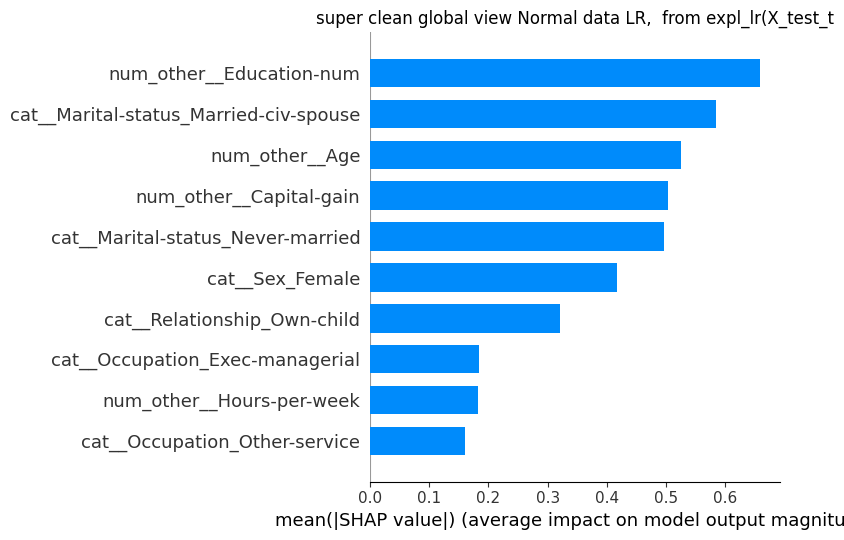

In [148]:
# Force plot 
# Top-10 features by mean |SHAP| — super clean global view Normal data
plt.title("super clean global view Normal data LR,  from expl_lr(X_test_t")
shap.summary_plot(
    shap_lr.values,                 # from expl_lr(X_test_t[:300])
    X_test_t[:300],
    feature_names=feature_names_orig,
    plot_type='bar',
    max_display=10
)

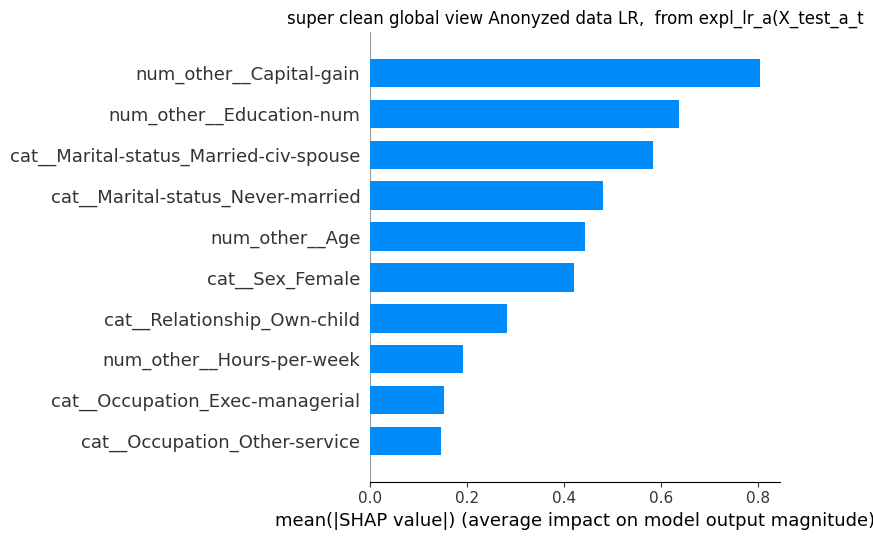

In [149]:
# Force plot 
# Top-10 features by mean |SHAP| — super clean global view Anonyzed data
plt.title("super clean global view Anonyzed data LR,  from expl_lr_a(X_test_a_t")
shap.summary_plot(
    shap_lr_a.values,               # from expl_lr_a(X_test_a_t[:300])
    X_test_a_t[:300],
    feature_names=feature_names_anon,
    plot_type='bar',
    max_display=10
)

In [150]:
# Interpretation: bars show the average influence strength of each feature on predictions. Easy to compare Original vs Anonymized.

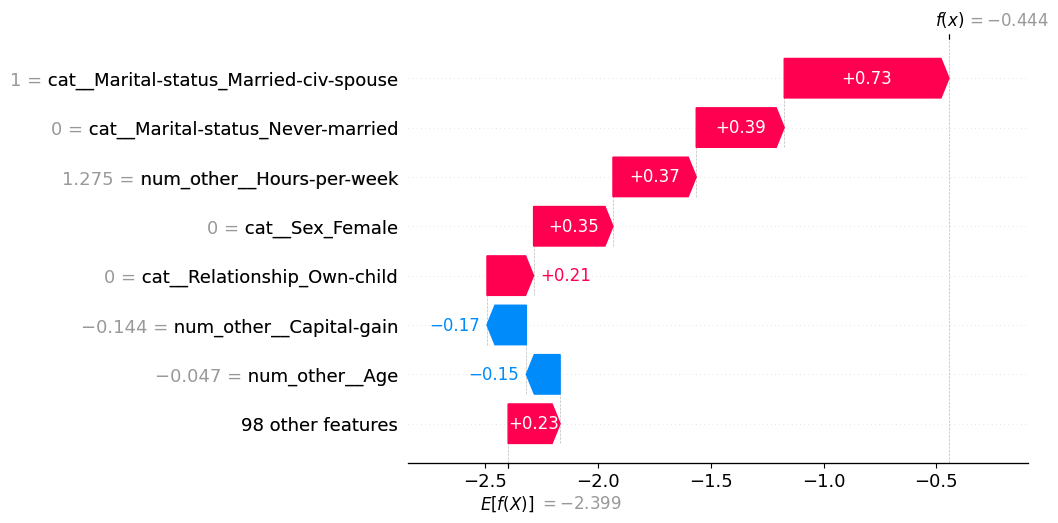

In [151]:
# One prediction, waterfall (top 8 features)
i = 0  # choose any index you want
row = X_test_t[i:i+1]
shap_row = expl_lr(row)   # SHAP for that single row

# make a 1-D dense feature vector for labeling
feat_vals = row.toarray()[0] if sparse.issparse(row) else np.asarray(row)[0]

# Build a SHAP Explanation and plot a compact waterfall
exp = shap.Explanation(
    values=shap_row.values[0],
    base_values=expl_lr.expected_value,
    data=feat_vals,
    feature_names=feature_names_orig
)
shap.waterfall_plot(exp, max_display=8)   # show top 8 contributions

In [152]:
# Minimal “leakage check” number (one line)
def mean_abs_shap(values, names):
    return pd.Series(np.abs(values).mean(axis=0), index=names).sort_values(ascending=False)

SENSITIVE_PREFIXES = ['sex_', 'race_', 'native-country_']  # adjust to your OHE names

def total_sensitive_importance(imp, prefixes):
    mask = imp.index.to_series().apply(lambda c: any(c.startswith(p) for p in prefixes))
    return float(imp[mask].sum())

imp_orig = mean_abs_shap(shap_lr.values, feature_names_orig)
imp_anon = mean_abs_shap(shap_lr_a.values, feature_names_anon)

print("Sensitive SHAP (Original):   ", total_sensitive_importance(imp_orig, SENSITIVE_PREFIXES))
print("Sensitive SHAP (Anonymized):", total_sensitive_importance(imp_anon, SENSITIVE_PREFIXES))

Sensitive SHAP (Original):    0.0
Sensitive SHAP (Anonymized): 0.0


In [153]:
# If anonymization worked, Anonymized ≈ 0 (or the sensitive features don’t even exist anymore).

In [154]:
#
# the original and anonymized SHAP bar plots side by side
#

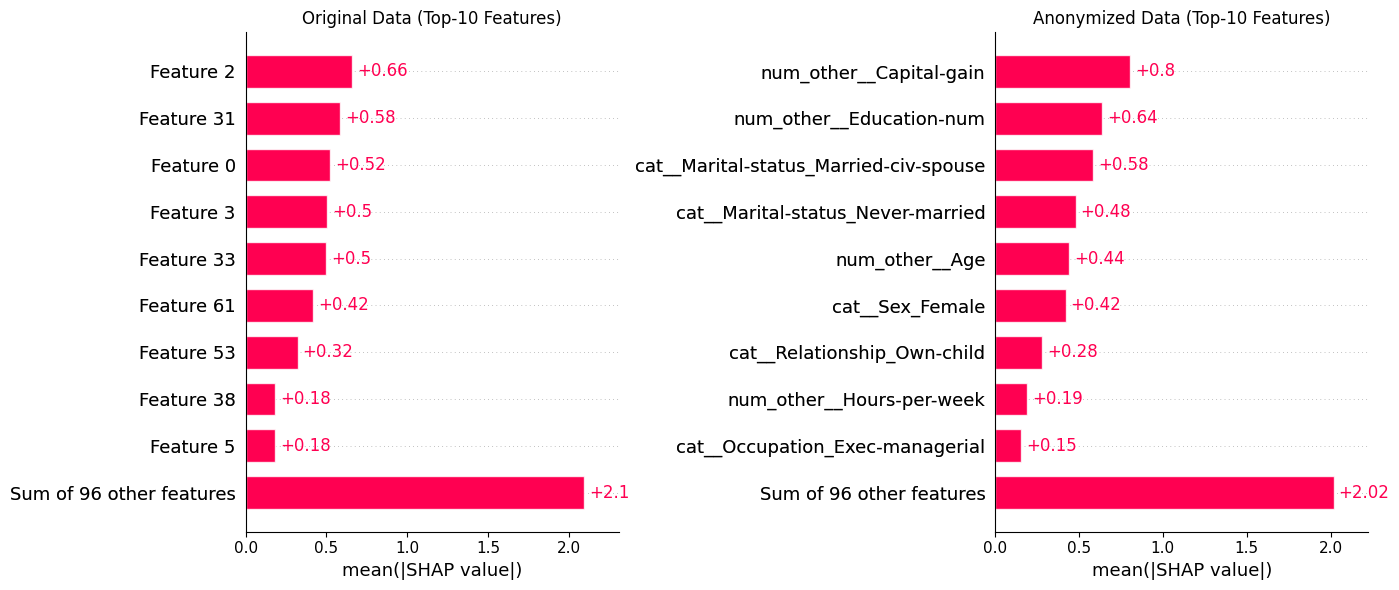

In [155]:
# Create side-by-side figure
# shap_lr  = expl_lr(X_test_t[:300])
# shap_lr_a = expl_lr_a(X_test_a_t[:300])

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Left: Original
shap.plots.bar(shap_lr, max_display=10, show=False, ax=axes[0])
axes[0].set_title("Original Data (Top-10 Features)")

# Right: Anonymized
shap.plots.bar(shap_lr_a, max_display=10, show=False, ax=axes[1])
axes[1].set_title("Anonymized Data (Top-10 Features)")

plt.tight_layout()
plt.show()

In [156]:
# shap_lr / shap_lr_a should be the Explanation objects returned by your explainer calls.

# This API reliably respects the ax argument.

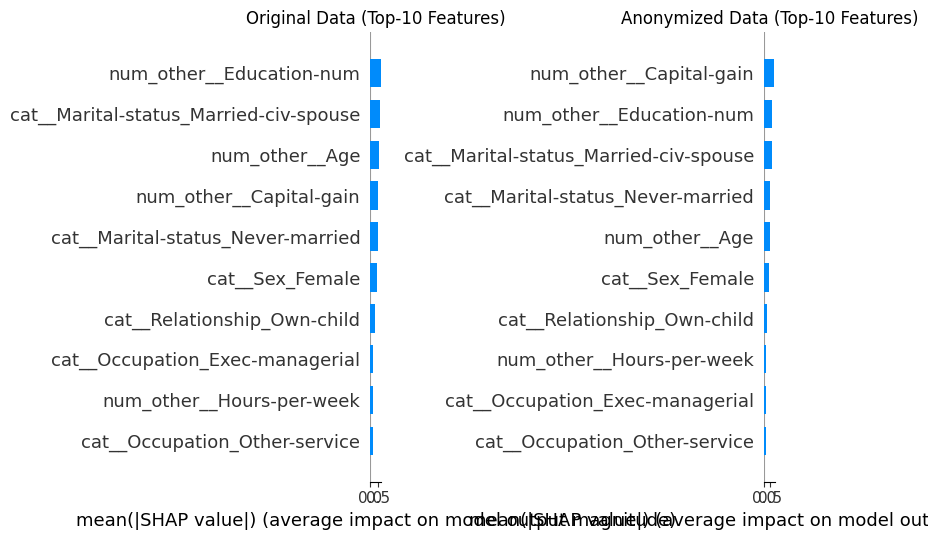

In [157]:
# Repeat for the Normal and Anonymized dataset to compare
# Classic summary_plot + plt.sca() 
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Left: Original
plt.sca(axes[0])  # set current axis
shap.summary_plot(
    shap_lr.values, X_test_t[:300],
    feature_names=feature_names_orig,
    plot_type='bar', max_display=10, show=False
)
axes[0].set_title("Original Data (Top-10 Features)")

# Right: Anonymized
plt.sca(axes[1])
shap.summary_plot(
    shap_lr_a.values, X_test_a_t[:300],
    feature_names=feature_names_anon,
    plot_type='bar', max_display=10, show=False
)
axes[1].set_title("Anonymized Data (Top-10 Features)")

plt.tight_layout()
plt.show()

In [158]:
# plt.sca(axes[i]) forces SHAP to draw on that subplot.

In [159]:
#
# Compute mean |SHAP| per feature
#
# feature_names_orig= normal dataset, feature_names_anon=Anonymized dataset

In [160]:
# Table for Feature

def mean_abs_shap_table(shap_explanation, feature_names, top_n=10):
    """Return a DataFrame of mean(|SHAP|) per feature, sorted desc, top_n."""
    vals = np.abs(shap_explanation.values).mean(axis=0)
    df = pd.DataFrame({'Feature': feature_names, 'Mean|SHAP|': vals})
    return df.sort_values('Mean|SHAP|', ascending=False).head(top_n).reset_index(drop=True)

In [161]:
# Build the two Top-10 tables
top10_orig = mean_abs_shap_table(shap_lr,  feature_names_orig, top_n=10)
top10_anon = mean_abs_shap_table(shap_lr_a, feature_names_anon, top_n=10)

print("Original – Top-10 mean |SHAP|")
display(top10_orig)

print("Anonymized – Top-10 mean |SHAP|")
display(top10_anon)

Original – Top-10 mean |SHAP|


,Feature,Mean|SHAP|
0,num_other__Education-num,0.659454
1,cat__Marital-status_Married-civ-spouse,0.584427
2,num_other__Age,0.524595
3,num_other__Capital-gain,0.503762
4,cat__Marital-status_Never-married,0.496419
5,cat__Sex_Female,0.417155
6,cat__Relationship_Own-child,0.321419
7,cat__Occupation_Exec-managerial,0.184794
8,num_other__Hours-per-week,0.181653
9,cat__Occupation_Other-service,0.160406


Anonymized – Top-10 mean |SHAP|


,Feature,Mean|SHAP|
0,num_other__Capital-gain,0.804179
1,num_other__Education-num,0.636221
2,cat__Marital-status_Married-civ-spouse,0.583485
3,cat__Marital-status_Never-married,0.479510
4,num_other__Age,0.442380
5,cat__Sex_Female,0.420613
6,cat__Relationship_Own-child,0.281015
7,num_other__Hours-per-week,0.190392
8,cat__Occupation_Exec-managerial,0.153153
9,cat__Occupation_Other-service,0.146448


In [162]:
#
# Compact side-by-side comparison (align on common features)
#

In [163]:
# Merge on feature name to compare where they overlap
cmp = (top10_orig.rename(columns={'Mean|SHAP|':'Mean|SHAP| (Orig)'})
                 .merge(top10_anon.rename(columns={'Mean|SHAP|':'Mean|SHAP| (Anon)'}),
                        on='Feature', how='outer'))

In [164]:
# fill NaN with 0 for features that appear only on one side
cmp = cmp.fillna(0)

In [165]:
# Add delta column (Anon - Orig)
cmp['Δ (Anon - Orig)'] = cmp['Mean|SHAP| (Anon)'] - cmp['Mean|SHAP| (Orig)']

# Sort by whichever side you care about (e.g., anonymized)
cmp = cmp.sort_values('Mean|SHAP| (Anon)', ascending=False).reset_index(drop=True)

# Round for neat display
display(cmp.round(4))

,Feature,Mean|SHAP| (Orig),Mean|SHAP| (Anon),Δ (Anon - Orig)
0,num_other__Capital-gain,0.5038,0.8042,0.3004
1,num_other__Education-num,0.6595,0.6362,-0.0232
2,cat__Marital-status_Married-civ-spouse,0.5844,0.5835,-0.0009
3,cat__Marital-status_Never-married,0.4964,0.4795,-0.0169
4,num_other__Age,0.5246,0.4424,-0.0822
5,cat__Sex_Female,0.4172,0.4206,0.0035
6,cat__Relationship_Own-child,0.3214,0.2810,-0.0404
7,num_other__Hours-per-week,0.1817,0.1904,0.0087
8,cat__Occupation_Exec-managerial,0.1848,0.1532,-0.0316
9,cat__Occupation_Other-service,0.1604,0.1464,-0.0140


# THE END